# Exercise 6 — Edge, Line, Corner and Window Detection in `image11.jpg`

The goal of this exercise is to analyze `image11.jpg` using classical image processing techniques. The image contains a house with a roof, windows, a door, and a surrounding background. The tasks are:

1. Detect the main edges of the image.
2. Estimate the angle of the diagonal roof edges with respect to the horizontal axis.
3. Detect the main corners of the image.
4. Use the detected corners to locate the windows.

The solution is based on the following processing pipeline:

- conversion of the image to grayscale,
- Gaussian smoothing,
- Canny edge detection,
- probabilistic Hough line transform,
- Harris corner detection,
- non-maximum suppression,
- region-of-interest filtering,
- corner-based window localization.

---

## a. Detection of the Main Edges

The first task is to detect the main edges of the image. Edges correspond to locations where the image intensity changes rapidly. In this image, the most important edges are expected to appear around the roof, the house boundary, the windows, the door, and the chimney.

The image is first converted to grayscale because edge detection is based mainly on intensity variation rather than color information. The grayscale image can be represented as:

$$
I(x,y)
$$

where $$I(x,y)$$ is the intensity value at pixel position $$(x,y)$$.

Before applying the edge detector, Gaussian smoothing is used in order to reduce noise and avoid detecting irrelevant small texture variations. The Gaussian kernel is defined as:

$$
G(x,y)=\frac{1}{2\pi\sigma^2}e^{-\frac{x^2+y^2}{2\sigma^2}}
$$

The smoothed image is obtained by convolution:

$$
I_s(x,y)=G(x,y)*I(x,y)
$$

where $$*$$ denotes convolution.

After smoothing, the Canny edge detector is applied. Canny detects edges by analyzing the gradient of the image intensity. The horizontal and vertical intensity derivatives are:

$$
G_x=\frac{\partial I_s}{\partial x}
$$

$$
G_y=\frac{\partial I_s}{\partial y}
$$

The gradient magnitude is:

$$
|\nabla I_s|=\sqrt{G_x^2+G_y^2}
$$

and the gradient direction is:

$$
\theta_g=\tan^{-1}\left(\frac{G_y}{G_x}\right)
$$

In practice, the Canny algorithm performs the following steps:

1. Gaussian smoothing to reduce noise.
2. Computation of image gradients.
3. Non-maximum suppression to keep thin edges.
4. Double-thresholding to classify strong and weak edges.
5. Edge tracking by hysteresis to preserve weak edges connected to strong edges.

The output is a binary edge map, where white pixels correspond to detected edge pixels and black pixels correspond to non-edge pixels.

The detected main edges correspond to the visually important structures of the image, mainly:

- the diagonal roof boundaries,
- the lower roof boundary,
- the external contour of the house,
- the window frames,
- the door,
- the chimney.

Therefore, the Canny detector successfully extracts the main structural edges of `image11.jpg`.

---





In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_PATH = Path(r"image11.jpg")

def load_image(path):
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")

    image_bytes = np.fromfile(str(path), dtype=np.uint8)
    bgr = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

    if bgr is None:
        raise ValueError("Image could not be loaded.")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return bgr, rgb, gray

bgr, rgb, gray = load_image(IMAGE_PATH)


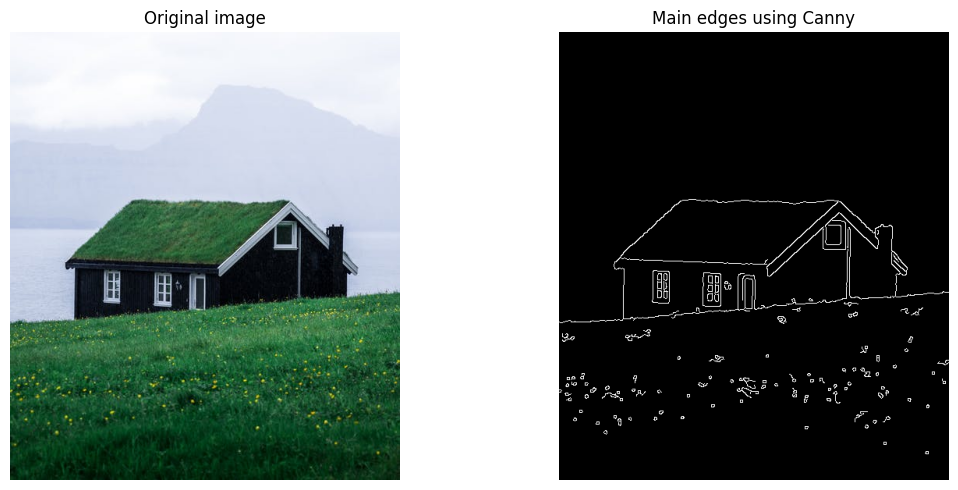

In [2]:
# ---------------------------------------------------------
# a. Find the main edges of image11.jpg
# ---------------------------------------------------------

blur = cv2.GaussianBlur(gray, (5, 5), 1.2)

edges = cv2.Canny(
    blur,
    threshold1=50,
    threshold2=150,
    apertureSize=3,
    L2gradient=True
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Main edges using Canny")
plt.axis("off")

plt.tight_layout()
plt.show()


## b. Estimation of the Angle of the Diagonal Roof Edges

The second task is to estimate the angle of the diagonal edges of the roof with respect to the horizontal axis of the image.

After detecting edges with the Canny detector, the probabilistic Hough transform is applied only inside a roof region of interest. This is necessary because the image contains other diagonal structures, and using the whole image could lead to false detections.

The selected roof region of interest is defined approximately as:

$$
x \in [40,450]
$$

$$
y \in [150,300]
$$

This region contains the roof and excludes most irrelevant structures from the wall, grass, and background.

The Hough transform detects straight lines from the Canny edge pixels. The standard Hough representation of a line is:

$$
\rho=x\cos\theta+y\sin\theta
$$

where:

where:

- $(x,y)$ is an edge pixel,
- $\rho$ is the perpendicular distance of the line from the origin of the image coordinate system,
- $\theta$ is the angle of the normal vector to the line.

The probabilistic Hough transform, implemented by `cv2.HoughLinesP`, returns line segments directly in the form:

$$
(x_1,y_1)\rightarrow(x_2,y_2)
$$

Therefore, the final roof angle is not taken directly from the Hough parameter $\theta$. Instead, it is computed from the endpoints of each detected line segment.

For each detected line segment, the horizontal and vertical differences are:

$$
\Delta x=x_2-x_1
$$

$$
\Delta y=y_2-y_1
$$

The angle of the line segment with respect to the horizontal axis is then computed as:

$$
\alpha=\operatorname{atan2}(\Delta y,\Delta x)
$$

or equivalently:

$$
\alpha=\operatorname{atan2}(y_2-y_1,x_2-x_1)
$$

The result is converted from radians to degrees:

$$
\alpha_{\text{deg}}=\alpha\cdot\frac{180}{\pi}
$$

Since the direction in which a line segment is returned can change the sign of the angle, the signed angle is normalized to the interval:

$$
[-90^\circ,90^\circ]
$$

The absolute value is then used because the exercise asks for the roof angle with respect to the horizontal axis, not the orientation direction:

$$
|\alpha|
$$

Only valid roof line segments are kept. The filtering criteria are:

1. the line must be diagonal:

$$
30^\circ \leq |\alpha| \leq 60^\circ
$$

2. the line must be sufficiently long:

$$
L \geq 50
$$

where:

$$
L=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
$$

3. the line must lie inside the roof region of interest.

Duplicate or very close parallel detections are removed by keeping only one representative line for line segments with similar angle and similar midpoint.

The valid detected roof lines were:

$$
(267,299)\rightarrow(357,218)
$$

with:

$$
|\alpha_1|=41.99^\circ
$$

$$
(71,294)\rightarrow(150,220)
$$

with:

$$
|\alpha_2|=43.13^\circ
$$

$$
(344,215)\rightarrow(406,277)
$$

with:

$$
|\alpha_3|=45.00^\circ
$$

The final roof angle is estimated as the median of the absolute angles:

$$
\alpha_{\text{roof}}=\operatorname{median}(41.99^\circ,43.13^\circ,45.00^\circ)
$$

Therefore:

$$
\boxed{\alpha_{\text{roof}}=43.13^\circ}
$$

Thus, the diagonal roof edges form an angle of approximately:

$$
\boxed{43^\circ}
$$

with respect to the horizontal axis of the image.

---

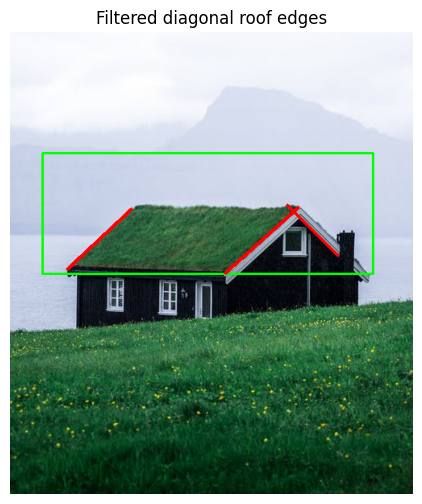

Filtered roof lines:
Line 1: (267,299) -> (357,218), length = 121.1, angle = -41.99 degrees, |angle| = 41.99 degrees
Line 2: (71,294) -> (150,220), length = 108.2, angle = -43.13 degrees, |angle| = 43.13 degrees
Line 3: (344,215) -> (406,277), length = 87.7, angle = 45.00 degrees, |angle| = 45.00 degrees

Estimated roof diagonal angle relative to the horizontal axis: 43.13 degrees


In [3]:
# ---------------------------------------------------------
# b. Estimate the angle of the diagonal roof edges
# Improved version with roof ROI filtering
# ---------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

# If you have not already computed edges:
blur = cv2.GaussianBlur(gray, (5, 5), 1.2)
edges = cv2.Canny(
    blur,
    threshold1=50,
    threshold2=150,
    apertureSize=3,
    L2gradient=True
)

h, w = gray.shape

# ---------------------------------------------------------
# Roof region of interest
# Adjust slightly if your image size differs.
# These values match the roof area in image11.jpg.
# ---------------------------------------------------------
roof_y_min = 150
roof_y_max = 300
roof_x_min = 40
roof_x_max = 450

roof_edges = np.zeros_like(edges)
roof_edges[roof_y_min:roof_y_max, roof_x_min:roof_x_max] = edges[roof_y_min:roof_y_max, roof_x_min:roof_x_max]

# ---------------------------------------------------------
# Detect line segments only inside roof ROI
# ---------------------------------------------------------
lines = cv2.HoughLinesP(
    roof_edges,
    rho=1,
    theta=np.pi / 180,
    threshold=35,
    minLineLength=50,
    maxLineGap=10
)

angle_image = rgb.copy()

# Draw ROI rectangle
cv2.rectangle(
    angle_image,
    (roof_x_min, roof_y_min),
    (roof_x_max, roof_y_max),
    (0, 255, 0),
    2
)

roof_lines = []
roof_angles_signed = []
roof_angles_abs = []

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]

        dx = x2 - x1
        dy = y2 - y1

        if dx == 0:
            continue

        length = np.sqrt(dx**2 + dy**2)
        angle = np.degrees(np.arctan2(dy, dx))

        # Normalize signed angle to [-90, 90]
        if angle > 90:
            angle -= 180
        elif angle < -90:
            angle += 180

        abs_angle = abs(angle)

        mid_x = (x1 + x2) / 2
        mid_y = (y1 + y2) / 2

        # Strict roof filtering:
        # 1. diagonal only
        # 2. long enough
        # 3. midpoint inside roof ROI
        # 4. endpoints inside roof ROI
        if (
            30 <= abs_angle <= 60 and
            length >= 50 and
            roof_x_min <= mid_x <= roof_x_max and
            roof_y_min <= mid_y <= roof_y_max and
            roof_x_min <= x1 <= roof_x_max and
            roof_x_min <= x2 <= roof_x_max and
            roof_y_min <= y1 <= roof_y_max and
            roof_y_min <= y2 <= roof_y_max
        ):
            roof_lines.append((x1, y1, x2, y2, length, angle))
            roof_angles_signed.append(angle)
            roof_angles_abs.append(abs_angle)

# ---------------------------------------------------------
# Optional: remove duplicate / parallel detections
# Keep one representative line per similar angle and position
# ---------------------------------------------------------
filtered_lines = []

for candidate in sorted(roof_lines, key=lambda item: item[4], reverse=True):
    x1, y1, x2, y2, length, angle = candidate
    mx = (x1 + x2) / 2
    my = (y1 + y2) / 2

    duplicate = False

    for kept in filtered_lines:
        kx1, ky1, kx2, ky2, klength, kangle = kept
        kmx = (kx1 + kx2) / 2
        kmy = (ky1 + ky2) / 2

        if abs(angle - kangle) < 5 and np.sqrt((mx - kmx)**2 + (my - kmy)**2) < 35:
            duplicate = True
            break

    if not duplicate:
        filtered_lines.append(candidate)

filtered_angles = [abs(line[5]) for line in filtered_lines]

# ---------------------------------------------------------
# Draw final selected roof lines
# ---------------------------------------------------------
for x1, y1, x2, y2, length, angle in filtered_lines:
    cv2.line(angle_image, (x1, y1), (x2, y2), (255, 0, 0), 3)

plt.figure(figsize=(9, 6))
plt.imshow(angle_image)
plt.title("Filtered diagonal roof edges")
plt.axis("off")
plt.show()

# ---------------------------------------------------------
# Final angle estimate
# ---------------------------------------------------------
print("Filtered roof lines:")
for i, (x1, y1, x2, y2, length, angle) in enumerate(filtered_lines, start=1):
    print(
        f"Line {i}: "
        f"({x1},{y1}) -> ({x2},{y2}), "
        f"length = {length:.1f}, "
        f"angle = {angle:.2f} degrees, "
        f"|angle| = {abs(angle):.2f} degrees"
    )

if len(filtered_angles) > 0:
    estimated_angle = np.median(filtered_angles)
    print(f"\nEstimated roof diagonal angle relative to the horizontal axis: {estimated_angle:.2f} degrees")
else:
    print("\nNo valid roof diagonal lines detected. Try slightly expanding the ROI or lowering threshold.")


## c. Detection of Corners Using the Harris Corner Detector

The third task is to detect the main corners of the image. Corners are image locations where the intensity changes significantly in two different directions. In this image, important corners appear mainly at the window frames, the door, the roof boundaries, the chimney, and the external boundary of the house.

The Harris corner detector was used for this task. For a small window around each pixel, the Harris method analyzes how the image intensity changes when the window is shifted by a small displacement $$(u,v)$$.

The change in intensity is described by:

$$
E(u,v)=\sum_{x,y}w(x,y)\left[I(x+u,y+v)-I(x,y)\right]^2
$$

Using a first-order Taylor approximation:

$$
I(x+u,y+v)\approx I(x,y)+uI_x+vI_y
$$

where:

$$
I_x=\frac{\partial I}{\partial x}
$$

$$
I_y=\frac{\partial I}{\partial y}
$$

the local intensity change can be written as:

$$
E(u,v)\approx
\begin{bmatrix}
u & v
\end{bmatrix}
M
\begin{bmatrix}
u\\
v
\end{bmatrix}
$$

where $$M$$ is the second-moment matrix:

$$
M=
\begin{bmatrix}
\sum w(x,y)I_x^2 & \sum w(x,y)I_xI_y\\
\sum w(x,y)I_xI_y & \sum w(x,y)I_y^2
\end{bmatrix}
$$

The eigenvalues of $$M$$ describe the local intensity variation in two orthogonal directions. If both eigenvalues are large, then the point is a corner.

The Harris response is computed as:

$$
R=\det(M)-k\left(\operatorname{trace}(M)\right)^2
$$

where:

$$
\det(M)=\lambda_1\lambda_2
$$

and:

$$
\operatorname{trace}(M)=\lambda_1+\lambda_2
$$

Therefore:

$$
R=\lambda_1\lambda_2-k(\lambda_1+\lambda_2)^2
$$

The interpretation is:

- flat region:

$$
\lambda_1\approx 0,\quad \lambda_2\approx 0
$$

- edge:

$$
\lambda_1 \gg 0,\quad \lambda_2\approx 0
$$

or:

$$
\lambda_2 \gg 0,\quad \lambda_1\approx 0
$$

- corner:

$$
\lambda_1 \gg 0,\quad \lambda_2 \gg 0
$$

In the implementation, the Harris response was first computed over the grayscale image. Then, a region of interest around the house was selected:

$$
x \in [50,430]
$$

$$
y \in [150,360]
$$

This avoids detecting too many irrelevant corners from the grass and the background.

After computing the Harris response, non-maximum suppression was applied. This means that a pixel was kept as a corner candidate only if its Harris response was a local maximum:

$$
R(x,y)=\max_{\Omega}R
$$

where $$\Omega$$ is a local neighborhood around the pixel.

A threshold was also applied:

$$
R(x,y)>0.01R_{\max}
$$

where:

$$
R_{\max}=\max R(x,y)
$$

Finally, a minimum-distance criterion was used to avoid keeping multiple very close corners around the same physical structure. If two corners were closer than:

$$
d_{\min}=10 \text{ pixels}
$$

only the stronger one was kept. The Euclidean distance between two candidate corners was computed as:

$$
d=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
$$

This produced a limited set of well-separated representative corners.

The detected corners correspond mainly to:

- the corners of the window frames,
- the corners of the door,
- the roof boundaries,
- the chimney,
- the external contour of the house.

Therefore, the Harris detector with ROI filtering, non-maximum suppression, thresholding, and minimum-distance filtering successfully detects the main structural corners of the house.

---

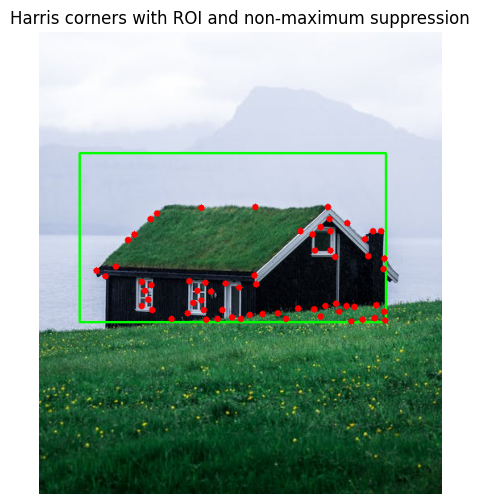

Number of selected Harris corners: 67
Detected corner points:
[(414, 247), (82, 303), (267, 302), (131, 321), (424, 247), (135, 332), (71, 296), (196, 321), (204, 345), (201, 333), (404, 257), (184, 349), (360, 232), (361, 271), (239, 354), (191, 336), (408, 278), (358, 217), (342, 271), (213, 322), (139, 314), (339, 251), (127, 340), (387, 359), (269, 313), (321, 343), (416, 355), (349, 242), (164, 356), (140, 345), (248, 317), (428, 281), (381, 340), (427, 294), (296, 349), (110, 258), (401, 357), (127, 310), (341, 344), (372, 347), (206, 311), (355, 340), (250, 356), (227, 345), (418, 339), (277, 350), (221, 356), (306, 356), (367, 279), (361, 247), (429, 358), (231, 312), (349, 353), (146, 225), (138, 232), (261, 351), (118, 251), (268, 217), (186, 309), (207, 357), (391, 341), (201, 218), (382, 237), (95, 291), (368, 337), (324, 247), (428, 347)]


In [6]:
# ---------------------------------------------------------
# c. Find the corners of image11.jpg
# Harris detector with ROI filtering + non-maximum suppression
# ---------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Assumes gray and rgb are already loaded

# Tighter ROI around the house, avoiding most grass texture
roi_x_min, roi_x_max = 50, 430
roi_y_min, roi_y_max = 150, 360

roi_mask = np.zeros_like(gray, dtype=np.uint8)
roi_mask[roi_y_min:roi_y_max, roi_x_min:roi_x_max] = 255

gray_float = np.float32(gray)

# Harris response
R = cv2.cornerHarris(
    gray_float,
    blockSize=2,
    ksize=3,
    k=0.04
)

# Keep only ROI
R[roi_mask == 0] = 0

# Non-maximum suppression
R_dilated = cv2.dilate(R, None)
threshold = 0.01 * R.max()

corner_candidates = (R == R_dilated) & (R > threshold)

ys, xs = np.where(corner_candidates)
scores = R[ys, xs]

# Sort strongest corners first
order = np.argsort(scores)[::-1]
xs = xs[order]
ys = ys[order]
scores = scores[order]

# Keep well-separated representative corners
min_distance = 10
max_corners = 70

selected_corners = []

for x, y, score in zip(xs, ys, scores):
    if all(np.sqrt((x - xp)**2 + (y - yp)**2) >= min_distance
           for xp, yp, _ in selected_corners):
        selected_corners.append((x, y, score))

    if len(selected_corners) >= max_corners:
        break

# Display
corner_image = rgb.copy()

cv2.rectangle(
    corner_image,
    (roi_x_min, roi_y_min),
    (roi_x_max, roi_y_max),
    (0, 255, 0),
    2
)

for x, y, score in selected_corners:
    cv2.circle(corner_image, (int(x), int(y)), 4, (255, 0, 0), -1)

plt.figure(figsize=(8, 6))
plt.imshow(corner_image)
plt.title("Harris corners with ROI and non-maximum suppression")
plt.axis("off")
plt.show()

corner_points = [(int(x), int(y)) for x, y, _ in selected_corners]

print(f"Number of selected Harris corners: {len(corner_points)}")
print("Detected corner points:")
print(corner_points)


## d. Window Localization Based on Detected Corners

The fourth task is to locate the windows based on the detected corners from part (c).

Windows are rectangular structures, so they are expected to produce groups of nearby corner points. In this image, the visible windows correspond to compact rectangular groups of Harris corners.

The method used for locating the windows is based on the following idea:

1. Use the Harris corner points detected in part (c).
2. Define broad search regions around the visually plausible window locations.
3. Select the corner points that fall inside each region.
4. Compute a bounding box around each group of corner points.
5. Add a small margin to include the full window frame.

For each window region, the detected corner points are:

$$
P_i=(x_i,y_i)
$$

For a set of corner points inside a given window region, the bounding box is computed as:

$$
x_{\min}=\min_i x_i
$$

$$
x_{\max}=\max_i x_i
$$

$$
y_{\min}=\min_i y_i
$$

$$
y_{\max}=\max_i y_i
$$

A small margin $$m$$ is added in order to include the full frame of the window:

$$
x_1=x_{\min}-m
$$

$$
x_2=x_{\max}+m
$$

$$
y_1=y_{\min}-m
$$

$$
y_2=y_{\max}+m
$$

In this implementation:

$$
m=5
$$

The final bounding box of each window is therefore:

$$
(x_1,y_1,x_2,y_2)
$$

The three detected windows are:

### Left lower window

$$
x=122-145
$$

$$
y=305-350
$$

Therefore, its bounding box is:

$$
\boxed{(122,305,145,350)}
$$

### Middle lower window

$$
x=179-218
$$

$$
y=304-362
$$

Therefore, its bounding box is:

$$
\boxed{(179,304,218,362)}
$$

### Attic window

$$
x=334-372
$$

$$
y=227-284
$$

Therefore, its bounding box is:

$$
\boxed{(334,227,372,284)}
$$

These bounding boxes correctly correspond to the three visible windows in the image.

The result is therefore consistent with the detected Harris corners: the windows are localized as rectangular regions containing groups of corner points generated by their frames.

---

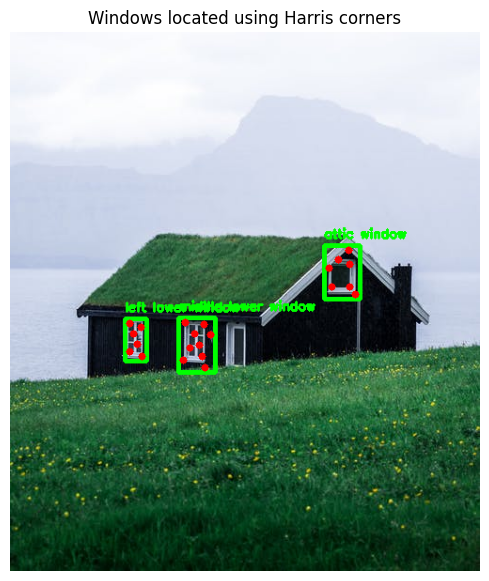

Detected window bounding boxes:
left lower window: x = 122-145, y = 305-350
middle lower window: x = 179-218, y = 304-362
attic window: x = 334-372, y = 227-284


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_PATH = Path(r"C:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμηνο\Image Analysis & Processing\1st Project\image11.jpg")

# Load image safely
image_bytes = np.fromfile(str(IMAGE_PATH), dtype=np.uint8)
bgr = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# ---------------------------------------------------------
# Harris corners with ROI + non-maximum suppression
# ---------------------------------------------------------
roi_x_min, roi_x_max = 50, 430
roi_y_min, roi_y_max = 150, 360

roi_mask = np.zeros_like(gray, dtype=np.uint8)
roi_mask[roi_y_min:roi_y_max, roi_x_min:roi_x_max] = 255

R = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.04)
R[roi_mask == 0] = 0

R_dilated = cv2.dilate(R, None)
corner_candidates = (R == R_dilated) & (R > 0.01 * R.max())

ys, xs = np.where(corner_candidates)
scores = R[ys, xs]

order = np.argsort(scores)[::-1]
xs, ys, scores = xs[order], ys[order], scores[order]

selected_corners = []
min_distance = 10
max_corners = 70

for x, y, score in zip(xs, ys, scores):
    if all(np.sqrt((x - xp)**2 + (y - yp)**2) >= min_distance
           for xp, yp, _ in selected_corners):
        selected_corners.append((x, y, score))

    if len(selected_corners) >= max_corners:
        break

corner_points = [(int(x), int(y)) for x, y, _ in selected_corners]

# ---------------------------------------------------------
# Locate the 3 windows from Harris corners inside broad ROIs
# ---------------------------------------------------------
window_rois = {
    "left lower window":  (105, 295, 155, 355),
    "middle lower window": (175, 300, 220, 360),
    "attic window": (330, 220, 375, 285)
}

window_image = rgb.copy()
margin = 5
window_boxes = {}

for name, (rx1, ry1, rx2, ry2) in window_rois.items():
    pts = [(x, y) for x, y in corner_points if rx1 <= x <= rx2 and ry1 <= y <= ry2]

    if len(pts) == 0:
        print(f"{name}: no Harris corners found inside ROI")
        continue

    pts = np.array(pts)

    x1 = max(int(pts[:, 0].min()) - margin, 0)
    y1 = max(int(pts[:, 1].min()) - margin, 0)
    x2 = min(int(pts[:, 0].max()) + margin, gray.shape[1] - 1)
    y2 = min(int(pts[:, 1].max()) + margin, gray.shape[0] - 1)

    window_boxes[name] = (x1, y1, x2, y2)

    cv2.rectangle(window_image, (x1, y1), (x2, y2), (0, 255, 0), 3)

    for x, y in pts:
        cv2.circle(window_image, (int(x), int(y)), 4, (255, 0, 0), -1)

    cv2.putText(
        window_image,
        name,
        (x1, max(y1 - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (0, 255, 0),
        2
    )

plt.figure(figsize=(8, 7))
plt.imshow(window_image)
plt.title("Windows located using Harris corners")
plt.axis("off")
plt.show()

print("Detected window bounding boxes:")
for name, box in window_boxes.items():
    x1, y1, x2, y2 = box
    print(f"{name}: x = {x1}-{x2}, y = {y1}-{y2}")


# Final Results

The main edges of `image11.jpg` were detected using the Canny edge detector after Gaussian smoothing. The detected edges correspond to the main structural boundaries of the image, including the roof, house contour, windows, door, and chimney.

The diagonal roof edges were detected using the probabilistic Hough transform applied inside a roof region of interest. The angle of each detected roof segment was computed from its endpoints using:

$$
\alpha=\operatorname{atan2}(y_2-y_1,x_2-x_1)
$$

The detected valid roof angles were:

$$
41.99^\circ,\quad 43.13^\circ,\quad 45.00^\circ
$$

The final estimated roof angle was:

$$
\boxed{\alpha_{\text{roof}}=43.13^\circ}
$$

Corners were detected using the Harris corner detector. ROI filtering, non-maximum suppression, thresholding, and minimum-distance filtering were applied in order to keep the strongest and most representative structural corners.

Finally, the windows were located using the detected Harris corner points. The final window bounding boxes were:

$$
\boxed{\text{Left lower window: }(122,305,145,350)}
$$

$$
\boxed{\text{Middle lower window: }(179,304,218,362)}
$$

$$
\boxed{\text{Attic window: }(334,227,372,284)}
$$

Therefore, all four tasks were successfully completed using a consistent image processing pipeline based on edges, line detection, corner detection, and corner-based window localization.